What I have:
reactants: omol, matpes, svp, tzvp opt; + tzvp sp
products: omol, matpes, svp opt; + tzvp sp

Goal: compare the new method to traditional one (svp opt + tzvp sp).
Assumption: svp opt + tzvp sp predict accurate results.
!!! even its absolute energies is very bad. But the relative energies are good. => it has good adsorption energy.

1. compare new opt binding energies wrt tranditional method energies. If a method have similar binding energy to tzvp does, it is good in predicting binding energy.


Thus:
1. omol opt have the overall lowest sp energy. => omol opt structure is the most close one to tzvp minimum for both reactants and products. => omol is good, if we trust tzvp. (But we don't care about this, the only factor to be compared is the binding energy wrt to svp opt + tzvp sp!!!)
2. use all of svp opt + tzvp sp for both products and reactants as reference.
3. But the problem is more than one stable configurations are observed. And different methods predict different minima.
4. Moreover, I don't where the svp opt minima is. What I use is omol opt, then use the lowest energy configuration, and use it to preform svp opt further. And for matpes,  => Three methods fall in the same minima in most of times. but for some case, matpes opt show significantly higher energies.

In [1]:
from lzn.universal import to_path, eV_to_kJdmol
from lzn.parse_tore_mspa_out import exclude_unwanted_sites, parse_vs_tolist
from lzn.universal import parse_lzn_stem, hartree_to_eV
from parseName_extractEnergy import parseName_extractEnergy
from plot_with_regression import plot_with_regression

from ase.io import read
from copy import deepcopy

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
# General Info
ads_l = ["co", "h2s", "h2o", "nh3"]
opt_l = ["omol25_low_s", "matpes_r2scan", "pbe0_def2svp"]
site_index = [f"{i:02d}" for i in range(0, 22, 2) if i != 16]
pj_path = to_path("~/organized")

r_dict = {} # Reactants dict
p_dict = {} # Products dict

### Calculations

###### Reactants energies

In [3]:
# cluster energy
r_dict["c opt energy"] = np.array([[-205.957535, -401.687866, -11994.7539400 * hartree_to_eV]])
r_dict["c sp energy"] = np.array([[-11998.1881525, -11998.1802856, -11998.1874453]]) * hartree_to_eV

# adsorbates tzvp sp energies
sp_ll = [] # [opt1:[ads1, ads2, ...], ...]
for opti in ["omol25_low_s", "matpes_r2scan", "pbe0_def2svp"]:
    sp_l = []
    for adsi in ads_l:
        pathi = pj_path / "041_adsorbates_sp" / f"{adsi}_opt-{opti}_sp-pbe0_def2tzvp.log"
        atoms = read(pathi, index= -1, format="gaussian-out")
        atoms_energy = atoms.get_potential_energy()
        sp_l.append(atoms_energy)
    sp_ll.append(sp_l)
r_dict["a sp energy"] = np.array(sp_ll)

# adsorbates opt energies
opt_ll = []
for opti in ["omol25_low_s", "matpes_r2scan"]:
    opt_l = []
    for adsi in ads_l:
        pathi = pj_path / "04_adsorbates_mlip_opt" / f"{adsi}_opt-{opti}.traj"
        atoms = read(pathi, index= -1, format="traj")
        atoms_energy = atoms.get_potential_energy()
        opt_l.append(atoms_energy)
    opt_ll.append(opt_l)
opt_l = []
for adsi in ads_l:
    pathi = pj_path / "04_adsorbates_g16_opt" / f"{adsi}_opt-pbe0_def2svp.log"
    atoms = read(pathi, index= -1, format="gaussian-out")
    atoms_energy = atoms.get_potential_energy()
    opt_l.append(atoms_energy)
opt_ll.append(opt_l)

r_dict["a opt energy"] = np.array(opt_ll)

# sum reactants energies
r_dict["sum opt energy"] = r_dict["a opt energy"] + r_dict["c opt energy"].T
r_dict["sum sp energy"] = r_dict["a sp energy"] + r_dict["c sp energy"].T
print(r_dict["sum opt energy"])
print(r_dict["sum sp energy"])


[[-2.14251288e+02 -2.13695118e+02 -2.15298692e+02 -2.18760224e+02]
 [-4.18301460e+02 -4.16964817e+02 -4.17079851e+02 -4.22245018e+02]
 [-3.29471545e+05 -3.37254669e+05 -3.28469627e+05 -3.27929882e+05]]
[[-329568.665488   -337351.95226184 -328565.82506111 -328025.30003137]
 [-329568.44325485 -337351.73821121 -328565.61023105 -328025.08409144]
 [-329568.64496413 -337351.93167862 -328565.80344041 -328025.2747021 ]]


###### Reactants properties

In [4]:
# surface potential
cat_vmax_uni, _x = exclude_unwanted_sites(pj_path / "05_mspa_clusters" / "tio12CDa_opt-pbe0_def2tzvpS_hs.out")
cat_v = [i[2] for i in cat_vmax_uni]
r_dict["c vsmax"] = np.array(cat_v)

ads_v_names = [f"{i}S_hs.out" for i in ads_l]
get_ads_vmin = lambda ads_v_name: parse_vs_tolist(pj_path / "05_mspa_adsorbates" / ads_v_name, vs="min")[0][2]
ads_vmin = list(map(get_ads_vmin, ads_v_names))
r_dict["a vsmin"] = ads_vmin

###### Products energies

In [5]:
p_dict["opt name"] = ["omol25", "r2scan", "svp"]
p_dict["opt index"] = [0, 1, 2]

get_opt_path = lambda index_, key_: pj_path / f"77{str(index_)}_{key_}_opt"
get_sp_path = lambda index_, key_: pj_path / f"79{str(index_)}_{key_}_opt_sp"
p_dict["opt path"] = list(map(get_opt_path, p_dict["opt index"], p_dict["opt name"]))
p_dict["sp path"] = list(map(get_sp_path, p_dict["opt index"], p_dict["opt name"]))

p_dict["opt energy"] = list(map(parseName_extractEnergy, p_dict["opt path"]))
p_dict["sp energy"] = list(map(parseName_extractEnergy, p_dict["sp path"]))


omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
13 matching files
11 matching files
10 matching files
10+10+10+10 energies extracted
omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted


###### Binding energies

In [6]:

# svp opt + tzvp sp as ref
ref_dE = (p_dict["sp energy"][2] - np.array([r_dict["sum sp energy"][2]]).T) * eV_to_kJdmol
print(ref_dE)

# iteration over all opt energies
# p_dict=opt*ads*sites; r_dict=opt*ads->opt*ads*1
array_dE = (np.array(p_dict["opt energy"]) - r_dict["sum opt energy"].reshape(3,4,1)) * eV_to_kJdmol

print(array_dE)


[[ -45.51795694  -40.85165766  -15.11599187  -23.21775653   -8.8147944
    -5.04457791   -8.94921994  -13.0502493    -0.76212657    0.37235152]
 [ -70.86613584  -63.39265309  -45.81021174  -39.01752086  -28.00670337
   -21.33189739  -27.06047354  -25.18297925  -14.66811851  -13.69064525]
 [-103.90838798  -95.66510893  -76.48137577  -65.14105816  -53.62351938
   -45.39809372  -80.36790186  -48.84563639  -37.93931376  -36.50579134]
 [-140.21959294 -130.73445289 -105.48292911  -92.05087649  -75.65279771
   -74.11504298 -114.29777927  -81.45961374  -62.66261656  -60.74390193]]
[[[ -40.34052126  -38.1041751   -22.26572084  -18.75146259  -13.28647447
    -10.93087614  -13.49258932  -21.71509973  -11.81128101  -12.10278631]
  [ -64.21469434  -60.59443416  -45.20648808  -44.78984163  -36.35091062
    -28.96758211  -29.56089844  -33.25771557  -26.88876659  -24.69806014]
  [-100.1142889   -97.96480542  -79.87233802  -73.15152154  -64.98348434
    -58.86334544  -87.46472588  -63.92493734  -52.501

### Demo

###### Dataframe

In [7]:
f_dE = np.insert(array_dE, 0, ref_dE, axis=0)
print(f_dE.shape) # methods*abs*sites

x = r_dict["c vsmax"]

# Convert to df
df_l = []
col_l = ["Vsmax", "ref", "omol", "matpes", "dft"]
for i, ads_ in enumerate(ads_l):
    body = np.insert(f_dE[:,i,:], 0, x, axis=0)
    df_i = pd.DataFrame(body.T, columns=col_l)
    print(ads_)
    print(df_i)
    df_l.append(df_i)



(4, 4, 10)
co
    Vsmax        ref       omol     matpes        dft
0  124.67 -45.517957 -40.340521 -47.470480 -51.633307
1  106.27 -40.851658 -38.104175 -43.006621 -47.202252
2   62.43 -15.115992 -22.265721 -23.711326 -25.984282
3   61.78 -23.217757 -18.751463 -15.181115 -30.895803
4   51.16  -8.814794 -13.286474  -9.474679 -17.211177
5   42.57  -5.044578 -10.930876  -7.498920 -14.982391
6   40.89  -8.949220 -13.492589 -13.894370 -16.800549
7   34.72 -13.050249 -21.715100 -15.743515 -24.824337
8   23.00  -0.762127 -11.811281  -3.883077  -9.820398
9   21.15   0.372352 -12.102786  -4.283529  -9.379839
h2s
    Vsmax        ref       omol     matpes        dft
0  124.67 -70.866136 -64.214694 -54.325639 -81.477006
1  106.27 -63.392653 -60.594434 -48.463143 -73.285975
2   62.43 -45.810212 -45.206488 -30.277924 -55.971072
3   61.78 -39.017521 -44.789842 -25.584395 -54.054983
4   51.16 -28.006703 -36.350911 -19.798456 -42.498061
5   42.57 -21.331897 -28.967582 -13.279338 -34.273161
6   40.89 

###### Plot

slope:  [np.float64(-0.45113043147417825), np.float64(-0.2927475995301117), np.float64(-0.4318652499430177), np.float64(-0.41260333641062724)]
R2:  [np.float64(0.940408693551509), np.float64(0.857341593411163), np.float64(0.9214189594323439), np.float64(0.9210167443108541)] 

slope:  [np.float64(-0.5661497802664721), np.float64(-0.39977313925927555), np.float64(-0.3977947610364319), np.float64(-0.5231018466601558)]
R2:  [np.float64(0.9647272703348646), np.float64(0.9570929747390147), np.float64(0.9159332017386472), np.float64(0.9541413632430672)] 

slope:  [np.float64(-0.6295442176820529), np.float64(-0.4574187196362106), np.float64(-0.5175060998112068), np.float64(-0.6051314755383492)]
R2:  [np.float64(0.8099169630703855), np.float64(0.7686312494534787), np.float64(0.7824872549941413), np.float64(0.8024874394023331)] 

slope:  [np.float64(-0.7233928822869664), np.float64(-0.5799319120937615), np.float64(-0.7003009442419866), np.float64(-0.6724753663281479)]
R2:  [np.float64(0.78371138

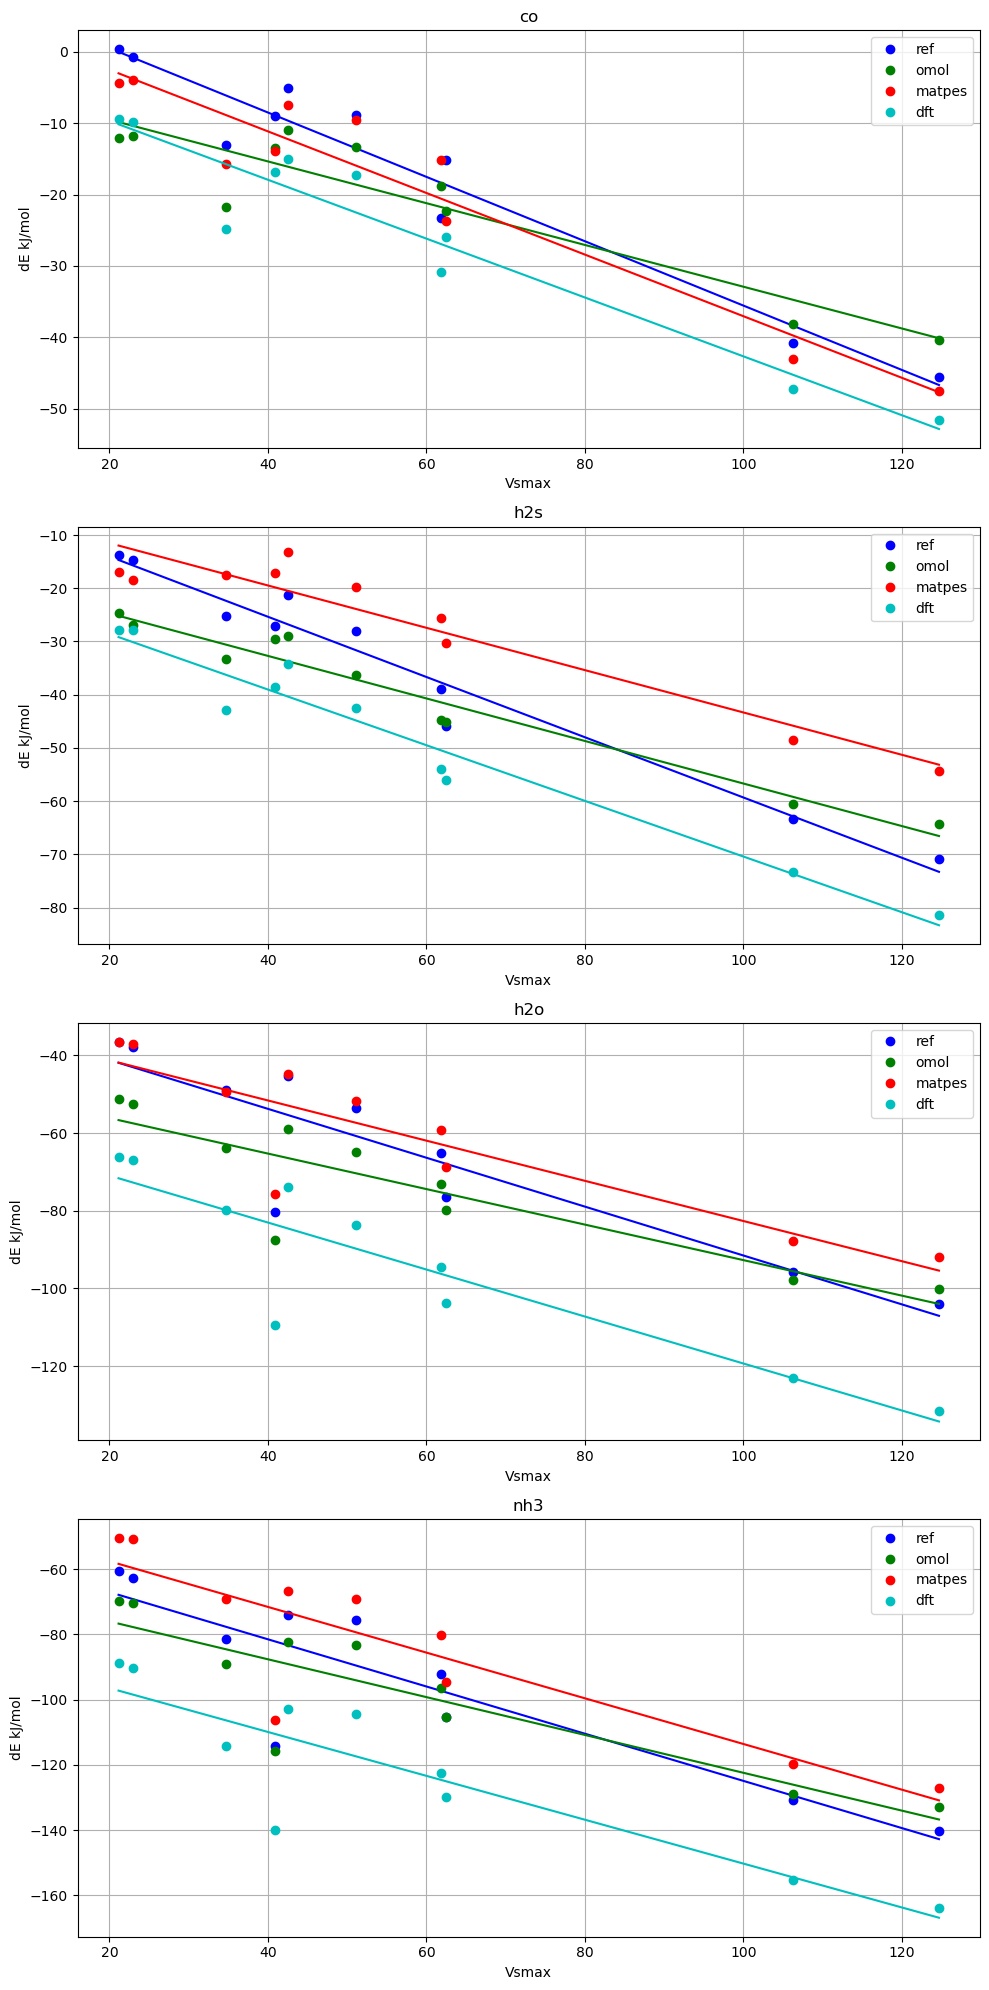

In [8]:


for i, df_ in enumerate(df_l):
    grid_name = fig1.add_subplot(gs[i, 0])
    grid_name.set_title(ads_l[i])

    slope_l, se_l = [], []
    for j, col_ in enumerate(["ref", "omol", "matpes", "dft"]):
        grid_name, slope, se = plot_with_regression(grid_name, j, df_["Vsmax"], df_[col_], col_)
        slope_l.append(slope)
        se_l.append(se)

    grid_name.legend()
    grid_name.set_xlabel("Vsmax")
    grid_name.set_ylabel("dE kJ/mol")
    grid_name.grid(True)

    print("slope: ", slope_l)
    print("R2: ", se_l, "\n")

fig1.tight_layout()
plt.show()

NOTE workflow: omol, matpes try all of configurations, and pick the lowest energy one. Then use omol optimized structure further opt by dft. Finally sp on all of them.\
dft: omol opt -> svp opt\
ref: omol opt -> svp opt -> tzvp sp (same structure as dft)\
two different configurations in matpes: co_06, h2s_14

###### E-Eref

slope:  [np.float64(0.6520831265304894), np.float64(0.9318445687664892), np.float64(0.9202481681608408)]
R2:  [np.float64(0.9205783263245734), np.float64(0.9284001316578674), np.float64(0.9915156891793683)] 

slope:  [np.float64(0.7013244655708567), np.float64(0.6923104082652485), np.float64(0.9237364995831301)]
R2:  [np.float64(0.9786401231098819), np.float64(0.9217338493974149), np.float64(0.9885407045135183)] 

slope:  [np.float64(0.7422559471214768), np.float64(0.8340667646159837), np.float64(0.9648697784332784)]
R2:  [np.float64(0.9903974758642855), np.float64(0.9946263074434889), np.float64(0.9983622436000248)] 

slope:  [np.float64(0.8122229567509927), np.float64(0.9755486799761448), np.float64(0.9292339833505179)]
R2:  [np.float64(0.995556028870976), np.float64(0.9936879041442473), np.float64(0.9932285580679413)] 



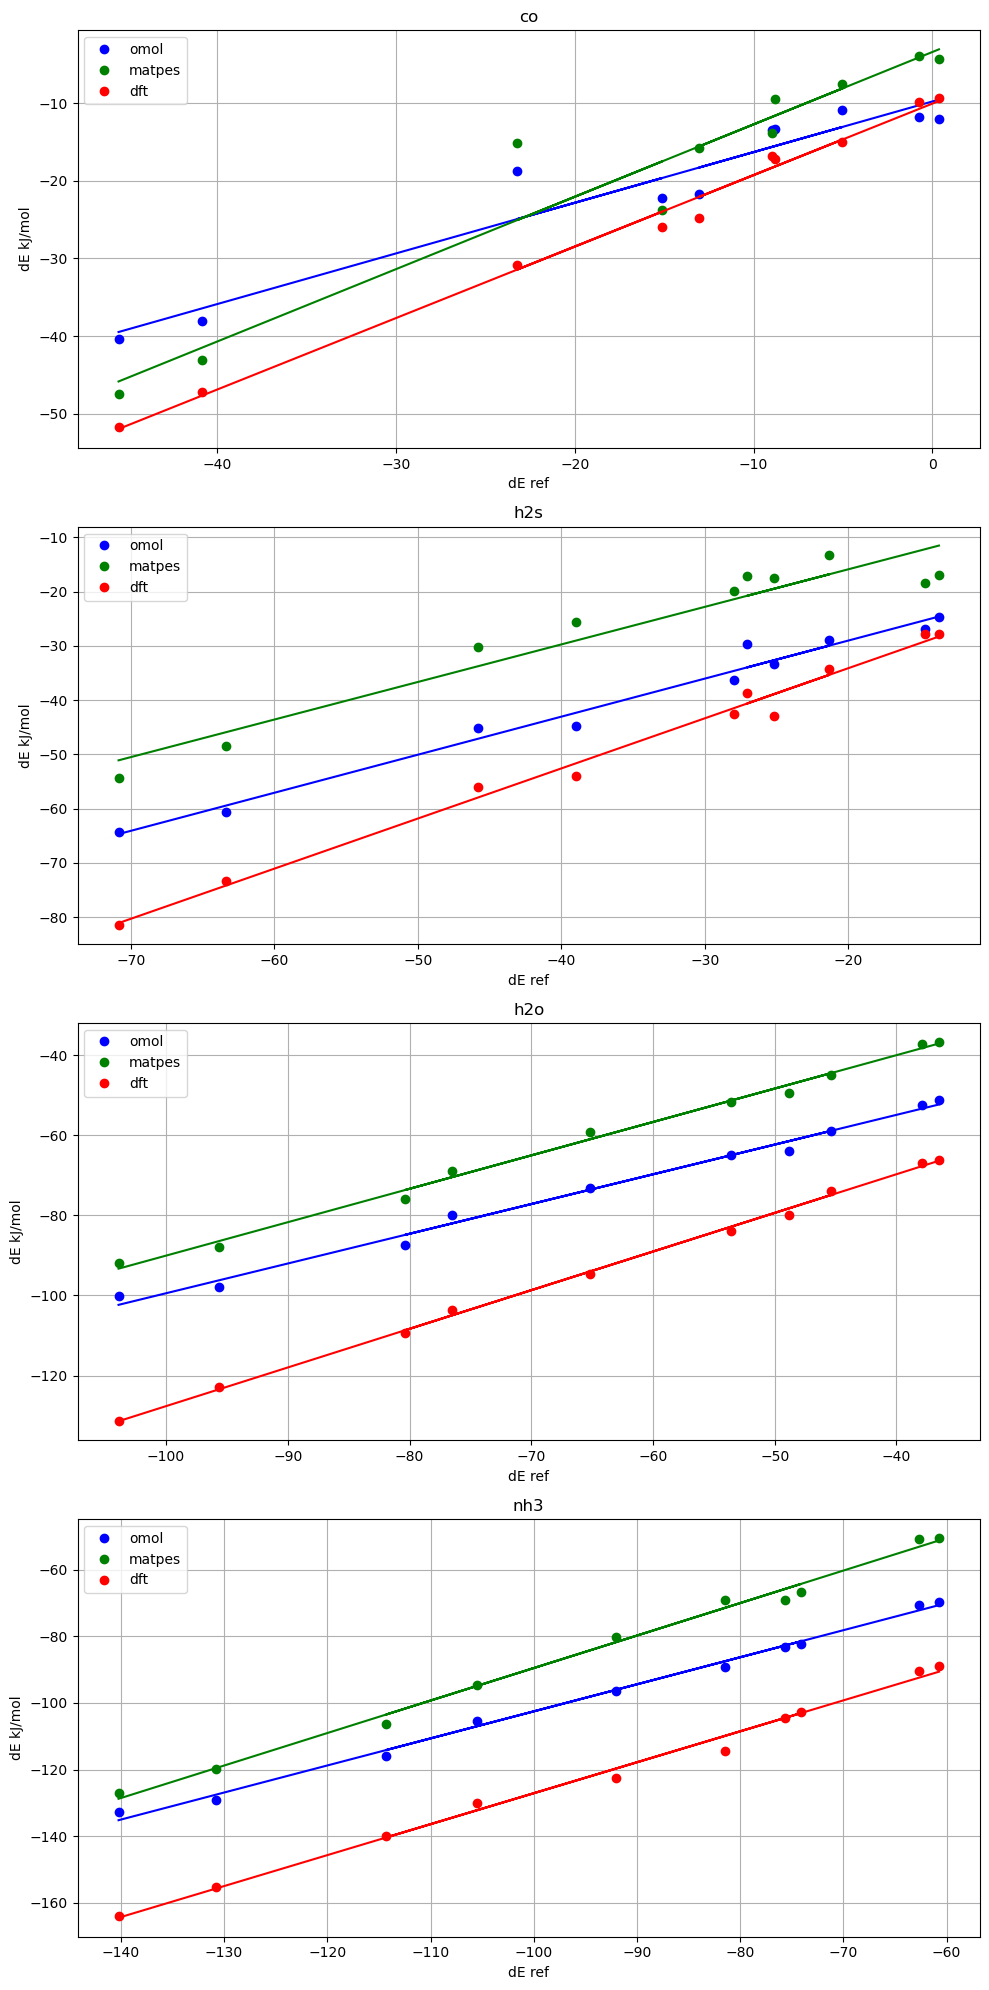

In [10]:
fig2 = plt.figure(1, figsize = (10,20))
gs = fig2.add_gridspec(4,1)

for i, df_ in enumerate(df_l):
    grid_name = fig2.add_subplot(gs[i, 0])
    grid_name.set_title(ads_l[i])

    slope_l, se_l = [], []
    for j, col_ in enumerate(["omol", "matpes", "dft"]):
        grid_name, slope, se = plot_with_regression(grid_name, j, df_["ref"], df_[col_], col_)
        slope_l.append(slope)
        se_l.append(se)

    grid_name.legend()
    grid_name.set_xlabel("dE ref")
    grid_name.set_ylabel("dE kJ/mol")
    grid_name.grid(True)

    print("slope: ", slope_l)
    print("R2: ", se_l, "\n")

fig2.tight_layout()
plt.show()